In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
import itertools
from tensorflow.keras.models import Model 
from sklearn.metrics import confusion_matrix
#imports

In [3]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data() #carrega os dados
X_train, X_test = X_train / 255.0, X_test / 255.0 #normaliza
X_train.shape #formato

(60000, 28, 28)

In [4]:
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1) #adiciona a dimensao
X_train.shape #shape do X_train

(60000, 28, 28, 1)

In [5]:
K = len(set(y_train)) #classes do conjunto de treino
K

10

In [6]:
i = Input(shape = X_train[0].shape) #camda de input
x = Conv2D(32, (3, 3), strides = 2, activation = 'relu')(i) #camda de convolucao
x = Conv2D(64, (3, 3), strides = 2, activation = 'relu')(x) #segunda camada de convolucao seguida
x = Conv2D(128, (3, 3), strides = 2, activation = 'relu')(x) #terceira seguida
x = Flatten()(x) #coloca em vetor
x = Dropout(0.2)(x) #desativa 20% dos neuronios
x = Dense(512, activation = 'relu')(x) #camada densa da rede neural
x = Dropout(0.2)(x) #desativa 20% dos neuronios dnv
x = Dense(K, activation = 'softmax')(x)  #camada de saida usando softmax pra classificar

model = Model(i, x) #modelo definido

W0000 00:00:1781093115.684173   25394 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy']) #compila o modelo

In [9]:
r = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 15) #treina

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8068 - loss: 0.5218 - val_accuracy: 0.8528 - val_loss: 0.4063
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8625 - loss: 0.3634 - val_accuracy: 0.8732 - val_loss: 0.3432
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8803 - loss: 0.3150 - val_accuracy: 0.8812 - val_loss: 0.3261
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8929 - loss: 0.2813 - val_accuracy: 0.8827 - val_loss: 0.3191
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9033 - loss: 0.2540 - val_accuracy: 0.8876 - val_loss: 0.3083
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9107 - loss: 0.2329 - val_accuracy: 0.8899 - val_loss: 0.3022
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9186 - loss: 0.2163 - val_accuracy: 0.8942 - val_loss: 0.3060
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9252 - loss: 0.1988 - 

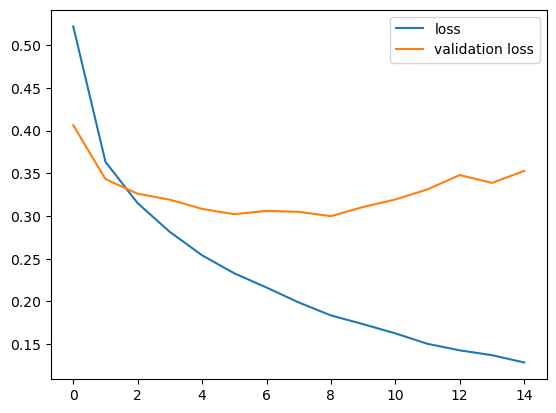

In [10]:
plt.plot(r.history['loss'], label = 'loss')
plt.plot(r.history['val_loss'], label = 'val_loss') #grafico que compara validation loss e loss
plt.legend()

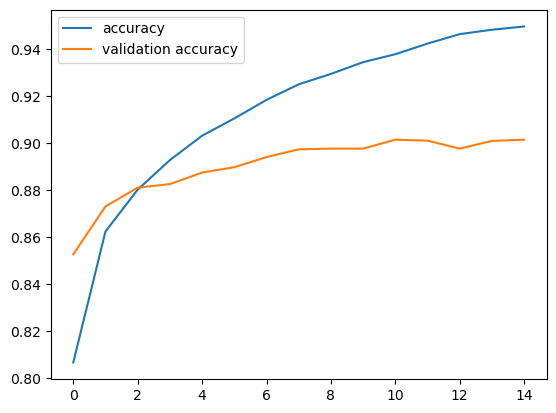

In [11]:
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc') #compara acuracia com validation accuracy
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
confusion_matrix, without normalization
[[873   0  29  23   2   2  65   0   6   0]
 [  3 977   1  15   1   0   2   0   1   0]
 [ 12   0 878  10  43   0  55   0   2   0]
 [ 13   2  21 918  25   0  21   0   0   0]
 [  1   1  61  25 824   0  87   0   1   0]
 [  1   0   0   0   0 968   0  18   1  12]
 [120   0  65  33  76   1 689   0  16   0]
 [  0   0   0   0   0   8   0 946   0  46]
 [  2   1   4   2   5   1   8   2 973   2]
 [  1   0   0   0   0   6   0  22   1 970]]


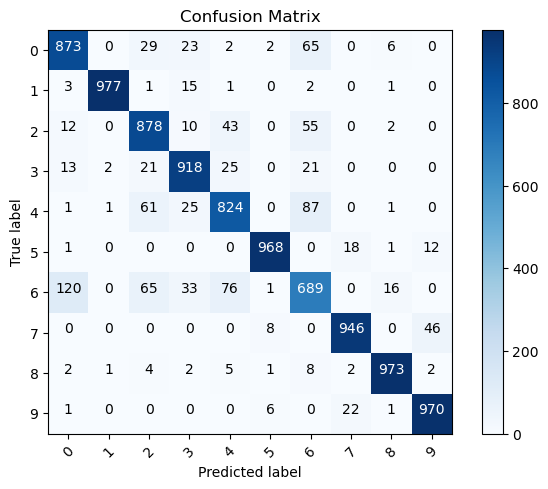

In [16]:
def plot_confusion_matrix(cm, classes, normalize = False, title = 'Confusion Matrix', cmap = plt.cm.Blues): #funcao pra mostrar a matriz de confusao
    if normalize: #se normaliza
        cm = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis] #joga os valores pra porcentagens
        print('Normalized Confusion Matrix')
    else: 
        print('Confusion_matrix, without normalization')

    print(cm) #mostra os valores 

    plt.imshow(cm, interpolation = 'nearest', cmap = cmap) #define a matriz colorida
    plt.title(title) #titulo
    plt.colorbar() #tons de azul q esta no parametro
    tick_marks = np.arange(len(classes)) #classes
    plt.xticks(tick_marks, classes, rotation = 45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd' #formatacao do texto
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment='center', color = 'white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show() #mostra

p_test = model.predict(X_test).argmax(axis = 1) #faz o teste
cm = confusion_matrix(y_test, p_test) #dados
plot_confusion_matrix(cm, list(range(10))) #chama a funcao pra fazer a imagem da matriz

In [17]:
labels = '''T-shirt/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split() #separando as labels

Text(0.5, 1.0, 'True label: Shirt Predicted: Dress')

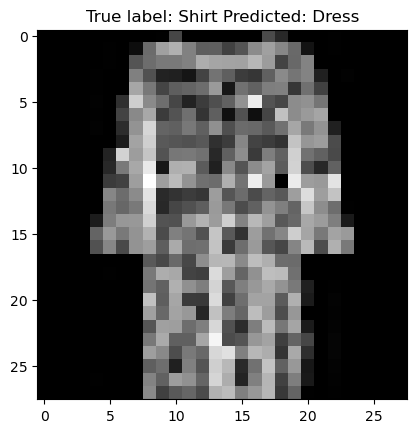

In [18]:
misclassified_idx = np.where(p_test != y_test)[0] #pega as imagens q foram prevista errada
i = np.random.choice(misclassified_idx) #pega uma aletaoriamente
plt.imshow(X_test[i].reshape(28, 28), cmap = 'gray') #mostra a imagem em cinza
plt.title('True label: %s Predicted: %s' % (labels[y_test[i]], labels[p_test[i]])) #nome real da classe